In [1]:
import os, sys
_nb_cwd = os.getcwd()
if os.path.basename(_nb_cwd).lower() == 'novoboard':
    PROJECT_ROOT = os.path.dirname(_nb_cwd)
    NOVOBOARD_DIR = _nb_cwd
else:
    PROJECT_ROOT = _nb_cwd
    NOVOBOARD_DIR = next(
        (os.path.join(_nb_cwd, n) for n in ('novoboard', 'NovoBoard')
         if os.path.isdir(os.path.join(_nb_cwd, n))),
        os.path.join(_nb_cwd, 'novoboard'),
    )
sys.path.insert(0, NOVOBOARD_DIR)   # so `import config` finds the repo's config.py
os.chdir(PROJECT_ROOT)              # all paths below are relative to project root
print('Project root:', os.getcwd())

# import libraries
from __future__ import print_function


import os
import sys
import csv
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import random
from multiprocessing import Pool
import time


import matplotlib
from matplotlib import pyplot
%matplotlib inline
from matplotlib_venn import venn3

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord



Project root: /home/nagendra/ub/dl/De-Novo-Peptide-Sequencing


In [2]:
########################################################################
########################################################################
########################################################################

In [3]:
# calculate fragment ion, amino acid, and peptide accuracies

import re
import csv
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import os.path
import config


col_precursor_mz = "m/z"
col_precursor_charge = "z"
col_rt_mean = "RT"
col_raw_sequence = "Peptide"
col_source_file = "Source File"
col_scan_list = "Scan"


def parse_raw_sequence(raw_sequence: str):
    raw_sequence_len = len(raw_sequence)
    peptide = []
    index = 0
    while index < raw_sequence_len:
        if raw_sequence[index] == "(":
            if peptide[-1] == "C" and raw_sequence[index:index + 8] == "(+57.02)":
                peptide[-1] = "C(Carbamidomethylation)"
                index += 8
            elif peptide[-1] == 'M' and raw_sequence[index:index + 8] == "(+15.99)":
                peptide[-1] = 'M(Oxidation)'
                index += 8
            elif peptide[-1] == 'N' and raw_sequence[index:index + 7] == "(+0.98)":
                peptide[-1] = 'N(Deamidation)'
                index += 7
            elif peptide[-1] == 'Q' and raw_sequence[index:index + 7] == "(+0.98)":
                peptide[-1] = 'Q(Deamidation)'
                index += 7
            elif peptide[-1] == 'S' and raw_sequence[index:index + 8] == "(+79.97)":
                peptide[-1] = "S(Phosphorylation)"
                index += 8
            elif peptide[-1] == 'T' and raw_sequence[index:index + 8] == "(+79.97)":
                peptide[-1] = "T(Phosphorylation)"
                index += 8
            elif peptide[-1] == 'Y' and raw_sequence[index:index + 8] == "(+79.97)":
                peptide[-1] = "Y(Phosphorylation)"
                index += 8
            else:  # unknown modification
                # logger.warning(f"unknown modification in seq {raw_sequence}")
                return False, peptide
        else:
            peptide.append(raw_sequence[index])
            index += 1

    for aa in peptide:
        if aa not in config.vocab:
            # logger.warning(f"unknown modification in seq {raw_sequence}")
            return False, peptide
    return True, peptide


class WorkerTest(object):
  """TODO(nh2tran): docstring.
     The WorkerTest should be stand-alone and separated from other workers.
  """


  def __init__(self, target_file, predicted_file, spectrum_file):
    """TODO(nh2tran): docstring."""

    print("".join(["="] * 80)) # section-separating line
    print("WorkerTest.__init__()")

    # we currently use deepnovo_config to store both const & settings
    # the settings should be shown in __init__() to keep track carefully
    self.MZ_MAX = config.MZ_MAX

    self.target_file = target_file
    self.predicted_file = predicted_file
    self.spectrum_file = spectrum_file
    self.accuracy_file = predicted_file + ".accuracy"
    self.denovo_only_file = predicted_file + ".denovo_only"
    self.scan2fea_file = predicted_file + ".scan2fea"
    self.multifea_file = predicted_file + ".multifea"
    print("target_file = {0:s}".format(self.target_file))
    print("predicted_file = {0:s}".format(self.predicted_file))
    print("spectrum_file = {0:s}".format(self.spectrum_file))
    print("accuracy_file = {0:s}".format(self.accuracy_file))
    print("denovo_only_file = {0:s}".format(self.denovo_only_file))
    print("scan2fea_file = {0:s}".format(self.scan2fea_file))
    print("multifea_file = {0:s}".format(self.multifea_file))

    self.target_dict = {}
    self.predicted_list = []
    self.spectrum_dict = {}


  def test_accuracy(self, db_peptide_list=None):
    """TODO(nh2tran): docstring."""

    print("".join(["="] * 80)) # section-separating line
    print("WorkerTest.test_accuracy()")

    # write the accuracy of predicted peptides
    accuracy_handle = open(self.accuracy_file, 'w')
    header_list = ["feature_id",
                   "feature_area",
                   "target_sequence",
                   "predicted_sequence",
                   "predicted_score",
                   "predicted_aa_score",
                   "recall_AA",
                   "aa_match",
                   "predicted_len",
                   "target_len",
                   "target_ion",
                   "matched_ion",
                   "unmatched_ion_list",
                   "scan_list_middle",
                   "scan_list_original"]
    header_row = "\t".join(header_list)
    print(header_row, file=accuracy_handle, end="\n")

    # write denovo_only peptides
    denovo_only_handle = open(self.denovo_only_file, 'w')
    header_list = ["feature_id",
                   "feature_area",
                   "predicted_sequence",
                   "predicted_score",
                   "predicted_score_max",
                   "scan_list_middle",
                   "scan_list_original"]
    header_row = "\t".join(header_list)
    print(header_row, file=denovo_only_handle, end="\n")

    self._get_target()
    target_count_total = len(self.target_dict)
    target_len_total = sum([len(x) for x in self.target_dict.values()])

    # this part is tricky!
    # some target peptides are reported by PEAKS DB but not found in
    #   db_peptide_list due to mistakes in cleavage rules.
    # if db_peptide_list is given, we only consider those target peptides,
    #   otherwise, use all target peptides
    target_dict_db = {}
    if db_peptide_list is not None:
      for feature_id, target in self.target_dict.items():
        target_simplied = target
        # remove the extension 'mod' from variable modifications
        target_simplied = ['M' if x=='M(Oxidation)' else x for x in target_simplied]
        target_simplied = ['N' if x=='N(Deamidation)' else x for x in target_simplied]
        target_simplied = ['Q' if x=='Q(Deamidation)' else x for x in target_simplied]
        if target_simplied in db_peptide_list:
          target_dict_db[feature_id] = target
        else:
          print("target not found: ", target_simplied)
    else:
      target_dict_db = self.target_dict
    target_count_db = len(target_dict_db)
    target_len_db = sum([len(x) for x in target_dict_db.values()])

    # we also skip target peptides with precursor_mass > MZ_MAX
    target_dict_db_mass = {}
    for feature_id, peptide in target_dict_db.items():
      if self._compute_peptide_mass(peptide) <= self.MZ_MAX:
        target_dict_db_mass[feature_id] = peptide
    target_count_db_mass = len(target_dict_db_mass)
    target_len_db_mass = sum([len(x) for x in target_dict_db_mass.values()])

    # read predicted peptides from deepnovo or peaks
    self._get_predicted_peaks_11()

    # note that the prediction has already skipped precursor_mass > MZ_MAX
    # we also skip predicted peptides whose feature_id's are not in target_dict_db_mass
    predicted_count_mass = len(self.predicted_list)
    predicted_count_mass_db = 0
    predicted_len_mass_db = 0
    predicted_only = 0
    # the recall is calculated on remaining peptides
    recall_AA_total = 0.0
    recall_peptide_total = 0.0
    # fragment ion accuracy
    target_ion_total = 0.0
    predicted_ion_total = 0.0
    matched_ion_total = 0.0
    recall_all_peptide_ions_total = 0.0

    # record scan with multiple features
    scan_dict = {}

    # read spectra to calculate fragment ion accuracy
    self._get_spectra()
    
    id_set = set()
    for index, predicted in enumerate(self.predicted_list):

      feature_id = predicted["feature_id"]
      if feature_id in id_set:
        continue
      else:
        id_set.add(feature_id)

      feature_area = str(predicted["feature_area"])
      feature_scan_list_middle = predicted["scan_list_middle"]
      feature_scan_list_original = predicted["scan_list_original"]
      if feature_scan_list_original:
        for scan in re.split(';|\r|\n', feature_scan_list_original):
          if scan in scan_dict:
            scan_dict[scan]["feature_count"] += 1
            scan_dict[scan]["feature_list"].append(feature_id)
          else:
            scan_dict[scan] = {}
            scan_dict[scan]["feature_count"] = 1
            scan_dict[scan]["feature_list"] = [feature_id]

      if feature_id in target_dict_db_mass:

        predicted_count_mass_db += 1

        target = target_dict_db_mass[feature_id]
        target_len= len(target)

        # if >= 1 denovo peptides reported, calculate the best accuracy
        best_recall_AA = -1
        best_aa_match = ''
        best_predicted_sequence = predicted["sequence"][0]
        best_predicted_score = predicted["score"][0]
        best_predicted_aa_score = predicted["aa_score"][0]
        for predicted_sequence, predicted_score, predicted_aa_score in zip(predicted["sequence"], predicted["score"], predicted["aa_score"]):
          predicted_AA_id = [config.vocab[x] for x in predicted_sequence]
          target_AA_id = [config.vocab[x] for x in target]
          recall_AA, aa_match = self._match_AA_novor(target_AA_id, predicted_AA_id)
          if (recall_AA > best_recall_AA
              or (recall_AA == best_recall_AA and predicted_score > best_predicted_score)):
            best_recall_AA = recall_AA
            best_aa_match = aa_match
            best_predicted_sequence = predicted_sequence[:]
            best_predicted_score = predicted_score
            best_predicted_aa_score = predicted_aa_score
        recall_AA = best_recall_AA
        aa_match = best_aa_match
        predicted_sequence = best_predicted_sequence[:]
        predicted_score = best_predicted_score
        predicted_aa_score = best_predicted_aa_score

        recall_AA_total += recall_AA
        if recall_AA == target_len:
          recall_peptide_total += 1
        predicted_len= len(predicted_sequence)
        predicted_len_mass_db += predicted_len

        if feature_id in self.spectrum_dict:
            target_ion, predicted_ion, matched_ion, unmatched_ion_list = self._match_ion(target, predicted_sequence, self.spectrum_dict[feature_id])
        else:
            target_ion, predicted_ion, matched_ion, unmatched_ion_list = 0, 0, 0, ''
        target_ion_total += target_ion
        predicted_ion_total += predicted_ion
        matched_ion_total += matched_ion
        recall_all_peptide_ions = matched_ion == target_ion
        recall_all_peptide_ions_total += recall_all_peptide_ions

        # convert to string format to print out
        target_sequence = ",".join(target)
        predicted_sequence = ",".join(predicted_sequence)
        predicted_score = "{0:.2f}".format(predicted_score)
        recall_AA = "{0:d}".format(recall_AA)
        predicted_len = "{0:d}".format(predicted_len)
        target_len = "{0:d}".format(target_len)
        target_ion = "{0:d}".format(target_ion)
        matched_ion = "{0:d}".format(matched_ion)
        print_list = [feature_id,
                      feature_area,
                      target_sequence,
                      predicted_sequence,
                      predicted_score,
                      predicted_aa_score,
                      recall_AA,
                      aa_match,
                      predicted_len,
                      target_len,
                      target_ion,
                      matched_ion,
                      unmatched_ion_list,
                      feature_scan_list_middle,
                      feature_scan_list_original]
        print_row = "\t".join(print_list)
        print(print_row, file=accuracy_handle, end="\n")
      else:
        predicted_only += 1
        predicted_sequence = ';'.join([','.join(x) for x in predicted["sequence"]])
        predicted_score = ';'.join(['{0:.2f}'.format(x) for x in predicted["score"]])
        if predicted["score"]:
          predicted_score_max = '{0:.2f}'.format(np.max(predicted["score"]))
        else:
          predicted_score_max = ''
        print_list = [feature_id,
                      feature_area,
                      predicted_sequence,
                      predicted_score,
                      predicted_score_max,
                      feature_scan_list_middle,
                      feature_scan_list_original]
        print_row = "\t".join(print_list)
        print(print_row, file=denovo_only_handle, end="\n")

    accuracy_handle.close()
    denovo_only_handle.close()

    multifea_dict = {}
    for scan_id, value in scan_dict.items():
      feature_count = value["feature_count"]
      feature_list = value["feature_list"]
      if feature_count > 1:
        for feature_id in feature_list:
          if feature_id in multifea_dict:
            multifea_dict[feature_id].append(scan_id + ':' + str(feature_count))
          else:
            multifea_dict[feature_id] = [scan_id + ':' + str(feature_count)]

    with open(self.scan2fea_file, 'w') as handle:
      header_list = ["scan_id",
                     "feature_count",
                     "feature_list"]
      header_row = "\t".join(header_list)
      print(header_row, file=handle, end="\n")
      for scan_id, value in scan_dict.items():
        print_list = [scan_id,
                      str(value["feature_count"]),
                      ";".join(value["feature_list"])]
        print_row = "\t".join(print_list)
        print(print_row, file=handle, end="\n")

    with open(self.multifea_file, 'w') as handle:
      header_list = ["feature_id",
                     "scan_list"]
      header_row = "\t".join(header_list)
      print(header_row, file=handle, end="\n")
      for feature_id, scan_list in multifea_dict.items():
        print_list = [feature_id,
                      ";".join(scan_list)]
        print_row = "\t".join(print_list)
        print(print_row, file=handle, end="\n")

    print("target_count_total = {0:d}".format(target_count_total))
    print("target_len_total = {0:d}".format(target_len_total))
    print("target_count_db = {0:d}".format(target_count_db))
    print("target_len_db = {0:d}".format(target_len_db))
    print("target_count_db_mass: {0:d}".format(target_count_db_mass))
    print("target_len_db_mass: {0:d}".format(target_len_db_mass))
    print()

    print("predicted_count_mass: {0:d}".format(predicted_count_mass))
    print("predicted_count_mass_db: {0:d}".format(predicted_count_mass_db))
    print("predicted_len_mass_db: {0:d}".format(predicted_len_mass_db))
    print("predicted_only: {0:d}".format(predicted_only))
    print()

    print("recall_AA_total = {0:.4f}".format(recall_AA_total / target_len_total))
    print("recall_AA_db = {0:.4f}".format(recall_AA_total / target_len_db))
    print("recall_AA_db_mass = {0:.4f}".format(recall_AA_total / target_len_db_mass))
    print("recall_peptide_total = {0:.4f}".format(recall_peptide_total / target_count_total))
    print("recall_peptide_db = {0:.4f}".format(recall_peptide_total / target_count_db))
    print("recall_peptide_db_mass = {0:.4f}".format(recall_peptide_total / target_count_db_mass))
    print("precision_AA_mass_db  = {0:.4f}".format(recall_AA_total / predicted_len_mass_db))
    print("precision_peptide_mass_db  = {0:.4f}".format(recall_peptide_total / predicted_count_mass_db))
    print()

    print("recall_ion = {0:.4f}".format(matched_ion_total / target_ion_total))
    print("precision_ion = {0:.4f}".format(matched_ion_total / predicted_ion_total))
    print("recall_all_peptide_ions = {0:.4f}".format(recall_all_peptide_ions_total / target_count_db_mass))
    print("target_ion_total =", target_ion_total)
    print("matched_ion_total =", matched_ion_total)
    print()

  
  def _compute_peptide_mass(self, peptide):
    """TODO(nh2tran): docstring.
    """

    #~ print("".join(["="] * 80)) # section-separating line ===
    #~ print("WorkerDB: _compute_peptide_mass()")

    peptide_mass = (config.mass_N_terminus
                    + sum(config.mass_AA[aa] for aa in peptide)
                    + config.mass_C_terminus)

    return peptide_mass


  def _get_predicted_peaks_11(self): # nh2tran
    """TODO(nh2tran): docstring."""

    print("".join(["="] * 80)) # section-separating line
    print("WorkerTest._get_predicted_peaks_11()")

    predicted_list = []
    with open(self.predicted_file, 'r') as handle:
        csv_reader = csv.DictReader(handle)
        for row in csv_reader:
            predicted = {}
            # predicted["feature_id"] = row[col_source_file] + "||" + row[col_scan_list]
            predicted["feature_id"] = row[col_source_file].split('.mgf')[0] + '.mgf' + "||" + row[col_scan_list]
            # predicted["feature_id"] = 'mutated_peptides1.mgf' + "||" + row['Scan']
            raw_sequence = row["Peptide"]
            assert raw_sequence, "Error: wrong format."
            okay, predicted["sequence"] = parse_raw_sequence(raw_sequence)
            if not okay:
                # skip unknown mod
                continue
            # skip peptides with precursor_mass > MZ_MAX
            if self._compute_peptide_mass(predicted["sequence"]) > self.MZ_MAX:
                continue
            predicted["feature_area"] = 0
            predicted["scan_list_middle"] = ""
            predicted["scan_list_original"] = ""
            predicted["sequence"] = [predicted["sequence"]]
            predicted["score"] = [float(row[col_score])]
            predicted["aa_score"] = [row[col_aa_score]]
            predicted_list.append(predicted)

    self.predicted_list = predicted_list

  
  def _get_target(self):
    """TODO(nh2tran): docstring."""

    print("".join(["="] * 80)) # section-separating line
    print("WorkerTest._get_target()")

    target_dict = {}
    with open(self.target_file, 'r') as handle:
      header_line = handle.readline()
      header = [x.strip('"') for x in header_line.strip().split(',')]
      print(header)
      raw_sequence_index = header.index(col_raw_sequence)
      source_file_index = header.index(col_source_file)
      scan_index = header.index(col_scan_list)

      for line in handle:
        line = [x.strip('"') for x in re.split(',|\r|\n', line)]
        feature_id = line[source_file_index] + "||" + line[scan_index]
        raw_sequence = line[raw_sequence_index]
        assert raw_sequence, "Error: wrong target format."
        okay, peptide = parse_raw_sequence(raw_sequence)
        if not okay:
          # skip unknown mod
          continue
        target_dict[feature_id] = peptide
    self.target_dict = target_dict

  
  def _get_spectra(self):
    """TODO(nh2tran): docstring."""

    print("".join(["="] * 80)) # section-separating line
    print("WorkerTest._get_spectra()")

    with open(self.spectrum_file, 'r') as f_in:
        while True:
            line = f_in.readline()
            if not line: # end of file
                break
            if line == '\n': # empty line
                continue
            peak_list = []
            while not "END IONS" in line:
                # skip blank lines inside the spectrum block
                if line.strip() == '':
                    line = f_in.readline()
                    continue
                # parse header lines
                if 'BEGIN IONS' in line or '=' in line:
                    if "TITLE=" in line:
                        source_file = self.spectrum_file.split('/')[-1]
                        _m = re.search(r'\.(\d+)\.(\d+)\.(\d+)\s*$', line)
                        if _m:
                            scan = _m.group(2)
                    if line[:6] == "SCANS=":
                        scan = re.split('[=\r\n]', line)[1]
                    line = f_in.readline()
                    continue
                # parse ions
                mz, intensity = re.split(' |\t|\r|\n', line)[:2]
                peak_list.append((float(mz), float(intensity)))
                line = f_in.readline()
            feature_id = source_file + '||' + scan
            self.spectrum_dict[feature_id] = peak_list
    print("len(self.spectrum_dict) =", len(self.spectrum_dict))
    print()

  
  def _match_AA_novor(self, target, predicted):
    """TODO(nh2tran): docstring."""
  
    #~ print("".join(["="] * 80)) # section-separating line
    #~ print("WorkerTest._test_AA_match_novor()")

    num_match = 0
    target_len = len(target)
    predicted_len = len(predicted)
    target_mass = [config.mass_ID[x] for x in target]
    target_mass_cum = np.cumsum(target_mass)
    predicted_mass = [config.mass_ID[x] for x in predicted]
    predicted_mass_cum = np.cumsum(predicted_mass)
  
    i = 0
    j = 0
    aa_match = []
    while i < target_len and j < predicted_len:
      if abs(target_mass_cum[i] - predicted_mass_cum[j]) < 0.5:
        if abs(target_mass[i] - predicted_mass[j]) < 0.1:
        #~ if  decoder_input[index_aa] == output[index_aa]:
          num_match += 1
          aa_match.append('1')
        else:
          aa_match.append('0')
        i += 1
        j += 1
      elif target_mass_cum[i] < predicted_mass_cum[j]:
        i += 1
      else:
        j += 1
        aa_match.append('0')
    aa_match = ' '.join(aa_match)

    return num_match, aa_match


  def _peptide_to_ions(self, peptide):
    """TODO(nh2tran): docstring."""
  
    #~ print("".join(["="] * 80)) # section-separating line
    #~ print("WorkerTest._test_AA_match_novor()")
    
    peptide_mass = self._compute_peptide_mass(peptide)
    prefix_mass = config.mass_AA['_GO'] + np.cumsum([config.mass_AA[aa] for aa in peptide[:-1]])
    suffix_mass = peptide_mass - prefix_mass
    # mass_loss = np.array([0])
    mass_loss = np.array([0, config.mass_H2O, config.mass_NH3])
    b_neutral = prefix_mass.reshape((prefix_mass.size, 1)) - mass_loss.reshape((1, -1)) # (m, 3)
    y_neutral = suffix_mass.reshape((suffix_mass.size, 1)) - mass_loss.reshape((1, -1))
    by_neutral = np.concatenate([b_neutral, y_neutral], axis=1) # (m, 6)
    by_charge1 = by_neutral + config.mass_H
    by_charge2 = (by_neutral + 2 * config.mass_H) / 2
    by_ions = [by_charge1, by_charge2]
#     isotopes = [-1, 1]
#     by_charge1_iso = [by_charge1 + x * config.mass_H  for x in isotopes]
#     by_charge2_iso = [by_charge2 + x * config.mass_H / 2  for x in isotopes]
#     by_ions = [by_charge1, by_charge2] + by_charge1_iso + by_charge2_iso
    by_ions = np.concatenate(by_ions, axis=1) # (m, i)
    
    return by_ions


  def _match_ion(self, target, predicted, spectrum):
    """TODO(nh2tran): docstring."""
  
    #~ print("".join(["="] * 80)) # section-separating line
    #~ print("WorkerTest._test_AA_match_novor()")
    
    target_by = self._peptide_to_ions(target).reshape(1, -1)
    predicted_by = self._peptide_to_ions(predicted).reshape(1, -1)
    mz_nby1 = np.array([x[0] for x in spectrum]).reshape(-1, 1)
    target_ion = np.any(np.abs(mz_nby1 - target_by) <= 0.02, axis=1)
    predicted_ion = np.any(np.abs(mz_nby1 - predicted_by) <= 0.02, axis=1)
    matched_ion = target_ion * predicted_ion
    mz_nby1 = mz_nby1.flatten()
    unmatched_ion_list = ';'.join(["{0:.5f}".format(x) for x in mz_nby1[np.flatnonzero(target_ion * (1-predicted_ion))]])
    target_ion = target_ion.sum()
    predicted_ion = predicted_ion.sum()
    matched_ion = matched_ion.sum()

    return target_ion, predicted_ion, matched_ion, unmatched_ion_list


# test_accuracy — run per (fraction, tool)
# Per-fraction because WorkerTest needs a single MGF per run; the
# merged CSV would reference two source files.
fractions = ['Ecoli_EV_1', 'Ecoli_EV_2']
tools = ['casanovo', 'instanovo', 'instanovoplus', 'novor']
col_score = 'Score'
col_aa_score = 'AA Score'

for fraction in fractions:
    target_file = f'ground_truth/ecoli/{fraction}.csv'
    spectrum_file = f'data_mgf/ecoli/{fraction}.mgf'
    for tool in tools:
        predicted_file = f'novoboard_in/{tool}/target/ecoli/{fraction}.csv'
        print(f'\n=== {fraction} / {tool} ===')
        worker_test = WorkerTest(target_file, predicted_file, spectrum_file)
        worker_test.test_accuracy()


Training vocab_reverse  ['_PAD', '_GO', '_EOS', 'A', 'R', 'N', 'D', 'C(Carbamidomethylation)', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'M(Oxidation)', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
Training vocab  {'_PAD': 0, '_GO': 1, '_EOS': 2, 'A': 3, 'R': 4, 'N': 5, 'D': 6, 'C(Carbamidomethylation)': 7, 'E': 8, 'Q': 9, 'G': 10, 'H': 11, 'I': 12, 'L': 13, 'K': 14, 'M': 15, 'M(Oxidation)': 16, 'F': 17, 'P': 18, 'S': 19, 'T': 20, 'W': 21, 'Y': 22, 'V': 23}
Training vocab_size  24

=== Ecoli_EV_1 / casanovo ===
WorkerTest.__init__()
target_file = ground_truth/ecoli/Ecoli_EV_1.csv
predicted_file = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv
spectrum_file = data_mgf/ecoli/Ecoli_EV_1.mgf
accuracy_file = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv.accuracy
denovo_only_file = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv.denovo_only
scan2fea_file = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv.scan2fea
multifea_file = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv.multifea
Worker

In [4]:
########################################################################
########################################################################
########################################################################

In [5]:
# Decoy FDR calculation

def read_denovo(denovo_csv, selected_features=None):
    denovo_psm = pd.read_csv(denovo_csv, keep_default_na=False)
    denovo_psm['feature_id'] = denovo_psm.apply(lambda row: row['Source File'].split('.mgf')[0] + '.mgf' + '||' + str(row['Scan']), axis=1)
    if selected_features:
        denovo_psm['selected_features'] = denovo_psm.apply(lambda row: row['feature_id'] in selected_features, axis=1)
        denovo_psm = denovo_psm[denovo_psm['selected_features']]
    return denovo_psm

def calculate_FDR(target_csv, decoy_csv, engine_score, fdr_list, selected_features=None):
    
    print("target_csv =", target_csv)
    print("decoy_csv =", decoy_csv)
    target_psm = read_denovo(target_csv, selected_features)
    decoy_psm = read_denovo(decoy_csv, selected_features)
    print("len(target_psm) =", len(target_psm)); print("len(decoy_psm) =", len(decoy_psm))
    dfs = pd.concat([target_psm, decoy_psm], keys=['target', 'decoy']).reset_index().rename(columns={'level_0': 'spectrum'})
    dfs['is_target'] = dfs.apply(lambda row: row['spectrum']=='target', axis=1)

    # target-decoy competition
    dfs.sort_values(by=[engine_score, 'is_target'], ascending=[False, False], inplace=True)
    # 1-1 competition on each scan id
#     dfs_fdr = dfs.drop_duplicates(subset=['feature_id'])
    # competition on whole dataset
    dfs_fdr = dfs
    dfs_fdr['feature_id'] = dfs_fdr.apply(lambda x: x['feature_id'] if x['is_target'] else x['feature_id']+'||decoy', axis=1)
    print("len(dfs) =", len(dfs))
    print("len(dfs_fdr) =", len(dfs_fdr))
    print("sum(dfs_fdr['is_target']) =", sum(dfs_fdr['is_target']))
    
    # fdr estimation
    cumsum = range(1, len(dfs_fdr) + 1)
    cumsum_target = np.cumsum(np.array(dfs_fdr['is_target'].astype(int)))
    cumsum_decoy = cumsum - cumsum_target
    estimated_fdr = cumsum_decoy / cumsum_target
    dfs_fdr['estimated_fdr'] = estimated_fdr

    score_list = []
    count_list = []
    for fdr in fdr_list:
        fdr_index = np.flatnonzero(estimated_fdr <= fdr)
        fdr_index = fdr_index[-1] if len(fdr_index) > 0 else 0
        score_list.append(dfs_fdr.iloc[fdr_index][engine_score])
        count_list.append(fdr_index + 1)

    return dfs, dfs_fdr, score_list, count_list



target_csv = novoboard_in_merged/casanovo/target/ecoli/Ecoli_EV.csv
decoy_csv = novoboard_in_merged/casanovo/decoy/ecoli/Ecoli_EV.csv
len(target_psm) = 21686
len(decoy_psm) = 21711
len(dfs) = 43397
len(dfs_fdr) = 43397
sum(dfs_fdr['is_target']) = 21686

=== casanovo ===
  FDR <= 1%: score cutoff = 0.8399, accepted = 2200
  FDR <= 5%: score cutoff = 0.4504, accepted = 4474
  FDR <= 10%: score cutoff = 0.1608, accepted = 5667
target_csv = novoboard_in_merged/instanovo/target/ecoli/Ecoli_EV.csv
decoy_csv = novoboard_in_merged/instanovo/decoy/ecoli/Ecoli_EV.csv
len(target_psm) = 21805
len(decoy_psm) = 21805
len(dfs) = 43610
len(dfs_fdr) = 43610
sum(dfs_fdr['is_target']) = 21805

=== instanovo ===
  FDR <= 1%: score cutoff = -0.1111, accepted = 2693
  FDR <= 5%: score cutoff = -1.3789, accepted = 6474
  FDR <= 10%: score cutoff = -2.8133, accepted = 8207
target_csv = novoboard_in_merged/instanovoplus/target/ecoli/Ecoli_EV.csv
decoy_csv = novoboard_in_merged/instanovoplus/decoy/ecoli/Ecoli_E

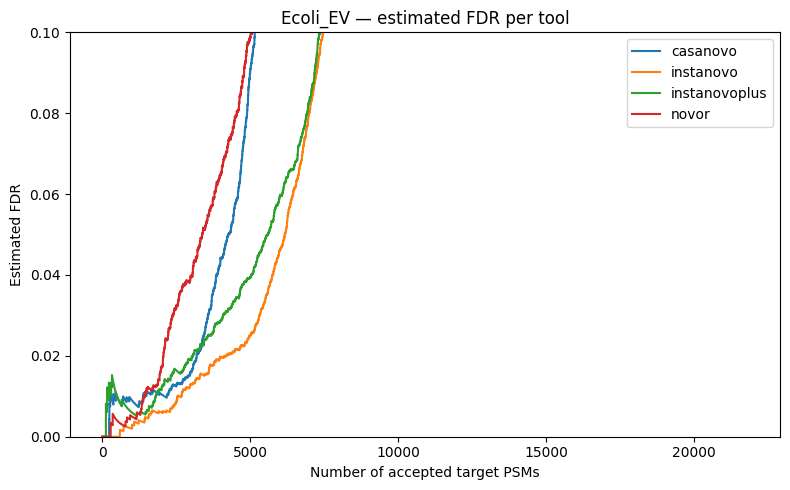

In [6]:
# Section 3 — estimated FDR per tool on merged Ecoli_EV
import os
os.makedirs('novoboard_out/ecoli', exist_ok=True)

fdr_levels = [0.01, 0.05, 0.10]
engine_score = 'Score'
tools = ['casanovo', 'instanovo', 'instanovoplus', 'novor']

fdr_results = {}
for tool in tools:
    target_csv = f'novoboard_in_merged/{tool}/target/ecoli/Ecoli_EV.csv'
    decoy_csv = f'novoboard_in_merged/{tool}/decoy/ecoli/Ecoli_EV.csv'
    dfs, dfs_fdr, score_list, count_list = calculate_FDR(
        target_csv, decoy_csv, engine_score, fdr_levels)
    fdr_results[tool] = (dfs_fdr, score_list, count_list)
    print(f'\n=== {tool} ===')
    for fdr, sc, ct in zip(fdr_levels, score_list, count_list):
        print(f'  FDR <= {fdr*100:.0f}%: score cutoff = {sc:.4f}, accepted = {ct}')
    dfs_fdr.to_csv(f'novoboard_out/ecoli/{tool}.fdr.csv', index=False)

# Plot estimated FDR vs. # accepted target PSMs, one curve per tool
fig, ax = pyplot.subplots(figsize=(8, 5))
for tool, (dfs_fdr, _, _) in fdr_results.items():
    target_estfdr = dfs_fdr.loc[dfs_fdr['is_target'], 'estimated_fdr'].values
    ax.plot(range(1, len(target_estfdr) + 1), target_estfdr, label=tool)
ax.set_xlabel('Number of accepted target PSMs')
ax.set_ylabel('Estimated FDR')
ax.set_ylim(0, 0.10)
ax.legend()
ax.set_title('Ecoli_EV — estimated FDR per tool')
pyplot.tight_layout()
pyplot.savefig('novoboard_out/ecoli/estimated_fdr.png', dpi=150)
pyplot.show()


In [7]:
# Decoy FDR validation

def validate_FDR(target_csv, decoy_csv, engine_score, db_csv, spectrum_file, p_decoy, T_pct):

    db_psm = pd.read_csv(db_csv, keep_default_na=False)
    db_psm['feature_id'] = db_psm.apply(lambda row: row['Source File'].split('.mgf')[0] + '.mgf' + '||' + str(row['Scan']), axis=1)
    selected_features = None # set(db_psm['feature_id'])

    dfs, dfs_fdr, score_list, count_list = calculate_FDR(target_csv, decoy_csv, engine_score, p_decoy, selected_features)

    target_decoy_csv = target_csv + '-' + decoy_csv.split('/')[-1]
    dfs_fdr.to_csv(target_decoy_csv, index=False)
    accuracy_file = target_decoy_csv + '.accuracy'
    if not os.path.isfile(accuracy_file):
        col_score = engine_score
        worker_test = WorkerTest(db_csv, target_decoy_csv, spectrum_file)
        worker_test.test_accuracy()

    denovo_df = dfs_fdr
    denovo_df = denovo_df.set_index('feature_id')
    accuracy_df = pd.read_csv(accuracy_file, delimiter ='\t', index_col='feature_id')
    denovo_df['db_peptide'] = accuracy_df.apply(
        lambda x: x['target_sequence'].replace('C(Carbamidomethylation)', 'C(+57.02)').replace('M(Oxidation)', 'M(+15.99)').replace(',', ''), 
        axis=1)
    denovo_df['recall_AA'] = accuracy_df['recall_AA']
    denovo_df['predicted_len'] = accuracy_df['predicted_len']
    denovo_df['recall_peptide'] = accuracy_df.apply(lambda x: x['recall_AA'] == x['predicted_len'], axis=1)
    denovo_df['target_ion'] = accuracy_df['target_ion']
    denovo_df['matched_ion'] = accuracy_df['matched_ion']
    denovo_df['recall_peptide_I'] = accuracy_df.apply(lambda x: x['matched_ion'] == x['target_ion'], axis=1)
    denovo_df['recall_peptide_T'] = accuracy_df.apply(lambda x: x['matched_ion'] >= x['target_ion']*T_pct, axis=1)
    print("len(denovo_df) =", len(denovo_df))
    print("  with recall_AA =", len(denovo_df[~denovo_df['recall_AA'].isna()]))
    print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))

    # calculate true FDR on annotated target spectra
    df = denovo_df
    df = df[~df['recall_AA'].isna()]
    df = df[df['is_target']]
    cumsum = range(1, len(df) + 1)
    cumsum_correct = np.cumsum(np.array(df['recall_peptide'].astype(int)))
    cumsum_false = cumsum - cumsum_correct
    true_fdr = cumsum_false / cumsum
    cumsum_correct = np.cumsum(np.array(df['recall_peptide_I'].astype(int)))
    cumsum_false = cumsum - cumsum_correct
    true_fdr_I = cumsum_false / cumsum
    cumsum_correct = np.cumsum(np.array(df['recall_peptide_T'].astype(int)))
    cumsum_false = cumsum - cumsum_correct
    true_fdr_T = cumsum_false / cumsum
    # only report entries with decreasing fdr from the bottom to avoid bumps
    min_est, min_true = 1, 1
    reported = []
    for x, y, z, v, w in list(zip(df['estimated_fdr'], cumsum, true_fdr, true_fdr_I, true_fdr_T))[::-1]:
        if x <= min_est and w <= min_true:
            min_est = x
            min_true = w
            reported.append((x, y, z, v, w))
    estimated_fdr, cumsum, true_fdr, true_fdr_I, true_fdr_T = zip(*reported)
    
    # calculate estimated FDR and #PSMs on all target spectra
    df = denovo_df
    df = df[df['is_target']]
    cumsum_full = range(1, len(df) + 1)
    # only report entries with decreasing fdr from the bottom to avoid bumps
    min_est = 1
    reported = []
    for x, y in list(zip(df['estimated_fdr'], cumsum_full))[::-1]:
        if x <= min_est:
            min_est = x
            reported.append((x, y))
    estimated_fdr_full, cumsum_full = zip(*reported)
    
    return {
        'denovo_df': denovo_df, 
        'df': df, 
        'estimated_fdr': estimated_fdr,
        'cumsum': cumsum,
        'true_fdr': true_fdr,
        'true_fdr_I': true_fdr_I,
        'true_fdr_T': true_fdr_T,
        'estimated_fdr_full': estimated_fdr_full,
        'cumsum_full': cumsum_full,
    }
    



=== Ecoli_EV_1 / casanovo ===
target_csv = novoboard_in/casanovo/target/ecoli/Ecoli_EV_1.csv
decoy_csv = novoboard_in/casanovo/decoy/ecoli/Ecoli_EV_1.csv
len(target_psm) = 10829
len(decoy_psm) = 10842
len(dfs) = 21671
len(dfs_fdr) = 21671
sum(dfs_fdr['is_target']) = 10829
len(denovo_df) = 21671
  with recall_AA = 1085
    is_target = 1085

=== Ecoli_EV_1 / instanovo ===
target_csv = novoboard_in/instanovo/target/ecoli/Ecoli_EV_1.csv
decoy_csv = novoboard_in/instanovo/decoy/ecoli/Ecoli_EV_1.csv


/tmp/ipykernel_60167/1724631944.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))


len(target_psm) = 10881
len(decoy_psm) = 10881
len(dfs) = 21762
len(dfs_fdr) = 21762
sum(dfs_fdr['is_target']) = 10881
len(denovo_df) = 21762
  with recall_AA = 1108
    is_target = 1108

=== Ecoli_EV_1 / instanovoplus ===
target_csv = novoboard_in/instanovoplus/target/ecoli/Ecoli_EV_1.csv
decoy_csv = novoboard_in/instanovoplus/decoy/ecoli/Ecoli_EV_1.csv
len(target_psm) = 10881
len(decoy_psm) = 10881


/tmp/ipykernel_60167/1724631944.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))


len(dfs) = 21762
len(dfs_fdr) = 21762
sum(dfs_fdr['is_target']) = 10881
len(denovo_df) = 21762
  with recall_AA = 1114
    is_target = 1114

=== Ecoli_EV_1 / novor ===
target_csv = novoboard_in/novor/target/ecoli/Ecoli_EV_1.csv
decoy_csv = novoboard_in/novor/decoy/ecoli/Ecoli_EV_1.csv


...

/tmp/ipykernel_60167/1724631944.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))


    is_target = 1243

=== Ecoli_EV_2 / instanovoplus ===
target_csv = novoboard_in/instanovoplus/target/ecoli/Ecoli_EV_2.csv
decoy_csv = novoboard_in/instanovoplus/decoy/ecoli/Ecoli_EV_2.csv
len(target_psm) = 10924
len(decoy_psm) = 10924
len(dfs) = 21848
len(dfs_fdr) = 21848
sum(dfs_fdr['is_target']) = 10924
len(denovo_df) = 21848
  with recall_AA = 1250
    is_target = 1250

=== Ecoli_EV_2 / novor ===
target_csv = novoboard_in/novor/target/ecoli/Ecoli_EV_2.csv
decoy_csv = novoboard_in/novor/decoy/ecoli/Ecoli_EV_2.csv


/tmp/ipykernel_60167/1724631944.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))


len(target_psm) = 10784
len(decoy_psm) = 10784
len(dfs) = 21568
len(dfs_fdr) = 21568
sum(dfs_fdr['is_target']) = 10784
len(denovo_df) = 21568
  with recall_AA = 1273
    is_target = 1273


/tmp/ipykernel_60167/1724631944.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("    is_target =", len(denovo_df[~denovo_df['recall_AA'].isna()][denovo_df['is_target']]))


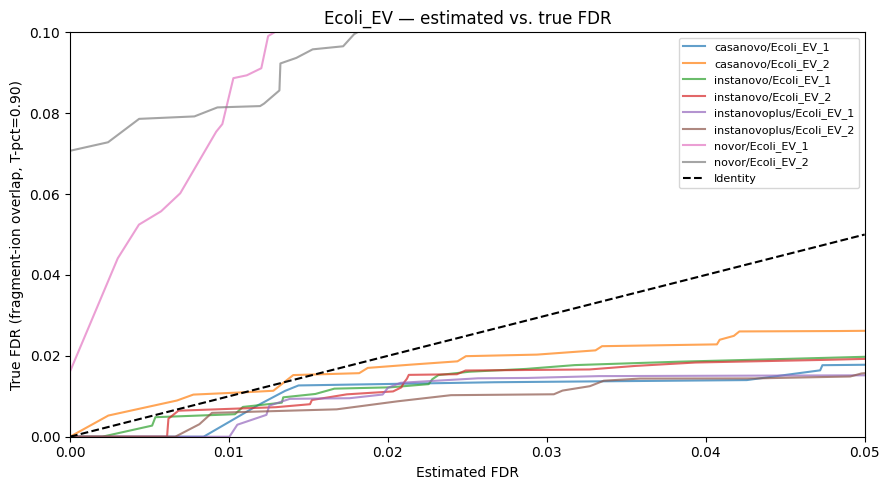

In [8]:
# Section 4 — estimated vs. true FDR validation per (fraction, tool)
import os
os.makedirs('novoboard_out/ecoli', exist_ok=True)

fractions = ['Ecoli_EV_1', 'Ecoli_EV_2']
tools = ['casanovo', 'instanovo', 'instanovoplus', 'novor']
p_decoy = [x/1000. for x in range(0, 50, 1)]
T_pct = 0.90
engine_score = 'Score'
col_score = engine_score
col_aa_score = 'AA Score'

validation_results = {}
for fraction in fractions:
    spectrum_file = f'data_mgf/ecoli/{fraction}.mgf'
    db_csv = f'ground_truth/ecoli/{fraction}.csv'
    for tool in tools:
        target_csv = f'novoboard_in/{tool}/target/ecoli/{fraction}.csv'
        decoy_csv = f'novoboard_in/{tool}/decoy/ecoli/{fraction}.csv'
        print(f'\n=== {fraction} / {tool} ===')
        results = validate_FDR(
            target_csv, decoy_csv, engine_score,
            db_csv, spectrum_file, p_decoy, T_pct)
        validation_results[(fraction, tool)] = results

# Plot estimated vs. true FDR (T-pct) per (tool, fraction)
fig, ax = pyplot.subplots(figsize=(9, 5))
for tool in tools:
    for fraction in fractions:
        r = validation_results.get((fraction, tool))
        if r is None:
            continue
        ax.plot(r['estimated_fdr'], r['true_fdr_T'], alpha=0.7,
                label=f'{tool}/{fraction}')
ax.plot([0, 0.05], [0, 0.05], 'k--', label='Identity')
ax.set_xlim(0, 0.05)
ax.set_ylim(0, 0.10)
ax.set_xlabel('Estimated FDR')
ax.set_ylabel('True FDR (fragment-ion overlap, T-pct=0.90)')
ax.legend(fontsize=8)
ax.set_title('Ecoli_EV — estimated vs. true FDR')
pyplot.tight_layout()
pyplot.savefig('novoboard_out/ecoli/validate_fdr.png', dpi=150)
pyplot.show()
